In [1]:
import random
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data.sampler import SubsetRandomSampler

from torchsummary import summary

import torchvision.transforms as T
from torchvision.datasets import MNIST

from sklearn.manifold import TSNE

import seaborn as sns
from matplotlib import pyplot as plt

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-squfjuhe because the default path (/home/20093355/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def make_fig(z, targets, epoch):

    model = TSNE()
    transformed = model.fit_transform(z)

    plt.scatter(transformed[:, 0], transformed[:, 1], c=targets, alpha=.4, s=3**2)

    plt.savefig(fname=f'{epoch}.png', format='png')

In [3]:
LR = 0.0001
EPOCH = 600
BATCH_SIZE = 256

LATENT_DIM = 3

In [4]:
class SubsetSequentialSampler(torch.utils.data.Sampler):
    def __init__(self, indices):
        self.indices = indices

    def __iter__(self):
        return (self.indices[i] for i in range(len(self.indices)))
    
    def __len__(self):
        return len(self.indices)

train = MNIST('./', train=True, download=True, transform=T.ToTensor())
test = MNIST('./', train=False, download=True, transform=T.ToTensor())

train_loader = torch.utils.data.DataLoader(train, batch_size=BATCH_SIZE, num_workers=2, shuffle=True)
test_loader = torch.utils.data.DataLoader(test, batch_size=BATCH_SIZE)

In [5]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()

        self.fc_1 = nn.Linear(28*28, 256)
        self.fc_2 = nn.Linear(256, 128)
        self.fc_3 = nn.Linear(128, 32)
        
        self.fc_mu = nn.Linear(32, LATENT_DIM)
        self.fc_var = nn.Linear(32, LATENT_DIM)

        self.leaky = nn.LeakyReLU(inplace=False)

    def forward(self, x):
        x = x.flatten(1)
        out = self.leaky(self.fc_1(x))
        out = self.leaky(self.fc_2(out))
        out = self.leaky(self.fc_3(out))
        
        out = out.view(out.size(0), -1)
        
        mu = self.fc_mu(out)
        log_var = self.fc_var(out)

        return [mu, log_var]

In [6]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()

        self.fc = nn.Linear(LATENT_DIM, 32)

        self.fc_1 = nn.Linear(32, 128)
        self.fc_2 = nn.Linear(128, 256)
        self.fc_3 = nn.Linear(256, 28*28)

        self.leaky = nn.LeakyReLU(inplace=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.leaky(self.fc(x))

        out = self.leaky(self.fc_1(out))
        out = self.leaky(self.fc_2(out))
        out = self.fc_3(out)
        
        out = out.view(out.size(0), 1, 28, 28)

        return self.sigmoid(out)

In [7]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        mu, log_var = self.encoder(x)

        z = self.reparameterize(mu, log_var)

        recon = self.decoder(z)

        return recon, mu, log_var
    
    def loss_function(self, target, recon, mu, log_var):
        recon_loss = F.binary_cross_entropy(recon, target, reduction='sum')
        kld_loss = 0.5 * torch.sum(mu.pow(2) + log_var.exp() - log_var - 1)

        loss = recon_loss + kld_loss

        return loss

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps * std + mu
    
    def generate(self, **kwargs):
        x = torch.rand(1, LATENT_DIM).cuda()
        return self.decoder(x)[0]
    
    def get_z(self, x):
        mu, log_var = self.encoder(x)

        return self.reparameterize(mu, log_var)

In [8]:
model = Model().cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 100, 200, 300, 400])

summary(model, input_size=(1, 28, 28))

Layer (type:depth-idx)                   Param #
├─Encoder: 1-1                           --
|    └─Linear: 2-1                       200,960
|    └─Linear: 2-2                       32,896
|    └─Linear: 2-3                       4,128
|    └─Linear: 2-4                       99
|    └─Linear: 2-5                       99
|    └─LeakyReLU: 2-6                    --
├─Decoder: 1-2                           --
|    └─Linear: 2-7                       128
|    └─Linear: 2-8                       4,224
|    └─Linear: 2-9                       33,024
|    └─Linear: 2-10                      201,488
|    └─LeakyReLU: 2-11                   --
|    └─Sigmoid: 2-12                     --
Total params: 477,046
Trainable params: 477,046
Non-trainable params: 0


Layer (type:depth-idx)                   Param #
├─Encoder: 1-1                           --
|    └─Linear: 2-1                       200,960
|    └─Linear: 2-2                       32,896
|    └─Linear: 2-3                       4,128
|    └─Linear: 2-4                       99
|    └─Linear: 2-5                       99
|    └─LeakyReLU: 2-6                    --
├─Decoder: 1-2                           --
|    └─Linear: 2-7                       128
|    └─Linear: 2-8                       4,224
|    └─Linear: 2-9                       33,024
|    └─Linear: 2-10                      201,488
|    └─LeakyReLU: 2-11                   --
|    └─Sigmoid: 2-12                     --
Total params: 477,046
Trainable params: 477,046
Non-trainable params: 0

In [9]:
for epoch in range(EPOCH):
    model.train()
    for img, target in tqdm(train_loader, leave=False, total=len(train_loader)):
        img = img.cuda()
        target = target.cuda()

        recon, mu, log_var = model(img)

        optimizer.zero_grad()

        loss = model.loss_function(img, recon, mu, log_var)

        loss.backward()
        optimizer.step()

    scheduler.step()
    if not epoch % 50:
        print(loss)

tensor(21576.5703, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14657.6621, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14031.9531, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14176.9619, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14489.8369, device='cuda:0', grad_fn=<AddBackward0>)


...

tensor(14671.0557, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14172.0811, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14702.9092, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14513.6836, device='cuda:0', grad_fn=<AddBackward0>)


tensor(14064.4922, device='cuda:0', grad_fn=<AddBackward0>)


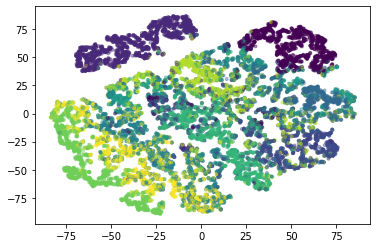

In [10]:
model.eval()
with torch.no_grad():
    features = torch.tensor([]).cuda()
    targets = torch.tensor([]).cuda()
    for (img, target) in train_loader:
        img = img.cuda()
        target = target.cuda()

        z = model.get_z(img)

        features = torch.cat((features, z), 0)
        targets = torch.cat((targets, target), 0)

features = features.cpu().numpy()
targets = targets.cpu().numpy()
make_fig(features[:15000], targets[:15000], 'train')

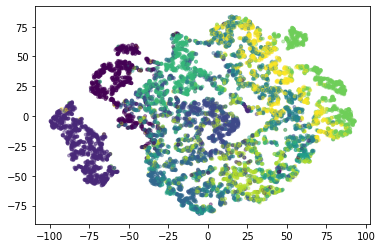

In [11]:
with torch.no_grad():
    features = torch.tensor([]).cuda()
    targets = torch.tensor([]).cuda()
    for (img, target) in test_loader:
        img = img.cuda()
        target = target.cuda()

        z = model.get_z(img)

        features = torch.cat((features, z), 0)
        targets = torch.cat((targets, target), 0)

features = features.cpu().numpy()
targets = targets.cpu().numpy()
make_fig(features[:], targets[:], 'test')

In [12]:
T.functional.to_pil_image(model.generate())